
# ARIMAX & Random Forest U.S. Macroeconomic Indicators

**Dependent Variable:** Consumer Price Index (CPI) 
**Models:** ARIMAX · Random Forest  
**Data Source:** FRED (Federal Reserve Economic Data)

In [8]:
pip install statsmodels


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# CONFIGURATION - change things here to control the whole notebook

import warnings
warnings.filterwarnings("ignore")

# Data source settings - point these to your actual CSV file
DATA_PATH   = "dataset_1.csv"
DATE_COL    = "observation_date"
DATE_FORMAT = "%d/%m/%Y"

# The target variable we are trying to predict
DEPENDENT_RAW = "CONSUMER PRICE INDEX FOR ALL URBAN CONSUMERS"

# Columns that need to be converted to Year-over-Year percentage change
# Leave out T10YFFM (already a spread), FEDERAL FUNDS EFFECTIVE RATE,
# and CAPACITY UTILIZATION (already in %). The rest - AHETPI, PAYEMS, BOGMBASE - do need conversion.
YOY_CONVERT_COLS = [
    "CONSUMER PRICE INDEX FOR ALL URBAN CONSUMERS",
    "INDUSTRIAL PRODUCTION",
    "MONEY SUPPLY",
    "PRODUCER PRICE INDEX BY COMMODITY",
    "AHETPI",
    "PAYEMS",
    "BOGMBASE",
]

# maps the raw CSV headers to shorter labels used throughout the notebook
RENAME_MAP = {
    "CONSUMER PRICE INDEX FOR ALL URBAN CONSUMERS": "CPI_YoY",
    "FEDERAL FUNDS EFFECTIVE RATE":                 "FedFunds_Rate",
    "MARKET YIELD ON US TREASURE SECURITIES":       "Treasury_10Y",
    "INDUSTRIAL PRODUCTION":                        "IndProd_YoY",
    "AHETPI":                                       "WageGrowth_YoY",
    "MONEY SUPPLY":                                 "M2_YoY",
    "T10YFFM":                                      "Yield_Spread",
    "PRODUCER PRICE INDEX BY COMMODITY":            "PPI_YoY",
    "PAYEMS":                                       "Payroll_YoY",
    "CAPACITY UTILIZATION TOTAL INDEX":             "Capacity_Util",
    "BOGMBASE":                                     "MonBase_YoY",
}

DEPENDENT = RENAME_MAP[DEPENDENT_RAW]

# If two features are correlated above this value, one of them gets dropped
CORR_THRESHOLD = 0.75

# Fraction of data to hold out for testing - 0.2 means 80% train, 20% test
TEST_RATIO = 0.2

# ARIMA order: (p, d, q) = (autoregressive lags, differencing, moving average terms)
ARIMAX_ORDER = (1, 0, 1)

# Random Forest settings - increase n_estimators for better accuracy (at the cost of speed)
RF_N_ESTIMATORS = 300
RF_RANDOM_STATE = 259

import matplotlib
matplotlib.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid":      True,
    "grid.alpha":     0.3,
})


In [11]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
print("Imports OK.")

Imports OK.


---
## Task 1 Data Loading & YoY % Conversion

In [12]:

raw = pd.read_csv(DATA_PATH)

# Parse the date column and set it as the index so we have a proper time series
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL], format=DATE_FORMAT)
raw.set_index(DATE_COL, inplace=True)
raw.sort_index(inplace=True)

# Quick sanity check to make sure the data really is monthly and nothing is missing
diffs = raw.index.to_series().diff().dropna()
print(f"Raw shape  : {raw.shape}")
print(f"Date range : {raw.index.min().date()}  →  {raw.index.max().date()}")
print(f"Avg gap    : {diffs.mean().days:.1f} days  (should be ~30 for monthly)")

raw.head()


Raw shape  : (699, 11)
Date range : 1968-01-01  →  2026-03-01
Avg gap    : 30.0 days  (should be ~30 for monthly)


,CONSUMER PRICE INDEX FOR ALL URBAN CONSUMERS,FEDERAL FUNDS EFFECTIVE RATE,MARKET YIELD ON US TREASURE SECURITIES,INDUSTRIAL PRODUCTION,AHETPI,MONEY SUPPLY,T10YFFM,PRODUCER PRICE INDEX BY COMMODITY,PAYEMS,CAPACITY UTILIZATION TOTAL INDEX,BOGMBASE
observation_date,,,,,,,,,,,
1968-01-01,34.1,4.61,5.53,36.3145,2.94,527.4,0.93,33.8,66804,87.3856,67.7
1968-02-01,34.2,4.71,5.56,36.4446,2.95,530.4,0.85,34.0,67215,87.3520,67.2
1968-03-01,34.3,5.05,5.74,36.5584,2.97,533.2,0.69,34.1,67295,87.2794,67.5
1968-04-01,34.4,5.76,5.64,36.6113,2.99,535.7,-0.12,34.1,67556,87.0627,68.0
1968-05-01,34.5,6.12,5.87,37.0220,3.00,538.9,-0.24,34.2,67652,87.6951,68.1


In [13]:
df = raw.copy()

# Only process columns that are actually in the dataset - avoids crashes if the CSV changes
yoy_cols = [col for col in YOY_CONVERT_COLS if col in df.columns]
for col in yoy_cols:
    df[col] = df[col].pct_change(periods=12) * 100

df = df.iloc[12:].copy()
df.rename(columns=RENAME_MAP, inplace=True)

# Recompute the dependent variable name in case RENAME_MAP changed above
DEPENDENT = RENAME_MAP[DEPENDENT_RAW]

print(f"After YoY conversion: {df.shape}")
print(f"Date range : {df.index.min().date()}  →  {df.index.max().date()}")
df.head()


After YoY conversion: (687, 11)
Date range : 1969-01-01  →  2026-03-01


,CPI_YoY,FedFunds_Rate,Treasury_10Y,IndProd_YoY,WageGrowth_YoY,M2_YoY,Yield_Spread,PPI_YoY,Payroll_YoY,Capacity_Util,MonBase_YoY
observation_date,,,,,,,,,,,
1969-01-01,4.692082,6.30,6.04,5.338914,6.122449,7.944634,-0.26,2.958580,3.944375,87.8712,7.680945
1969-02-01,4.678363,6.61,6.19,5.634580,6.440678,7.824284,-0.42,2.941176,3.695604,88.1166,7.142857
1969-03-01,5.247813,6.79,6.30,6.131559,6.397306,7.726932,-0.49,3.225806,3.878446,88.4902,6.370370
1969-04-01,5.523256,7.41,6.17,5.588439,6.354515,7.466866,-1.24,3.519062,3.724318,87.8507,6.470588
1969-05-01,5.507246,8.67,6.32,4.022203,6.333333,6.977176,-2.35,3.801170,3.955537,87.2081,7.782673


---
## Task 2a Data Preprocessing (Missing Values & Infinities)

In [14]:
# Check for missing and infinite values, then fill them in with the column median

print("Missing values BEFORE cleaning:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0] if missing_before.sum() > 0
      else "  None found.")

inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
print(f"Infinite values: {inf_count}")

# Treat infinities the same as missing values so we can handle both in one pass
# Fill every remaining gap with the median of that column
df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f"  Filled {n_missing} missing in '{col}' with median = {med:.4f}")

# Drop any rows that are still missing after the imputation above
df.dropna(inplace=True)

print(f"\nClean shape  : {df.shape}")
print(f"Remaining NaN: {df.isnull().sum().sum()}")


Missing values BEFORE cleaning:
CPI_YoY    1
dtype: int64
Infinite values: 0
  Filled 1 missing in 'CPI_YoY' with median = 3.1881

Clean shape  : (686, 11)
Remaining NaN: 0


---
## Task 2b Summary Statistics

In [15]:
# Summary statistics - mean, median, mode, standard deviation, and quartiles for every variable

desc = df.describe(percentiles=[0.25, 0.5, 0.75]).T
desc["mode"] = df.mode().iloc[0]
desc = desc[["mean", "50%", "mode", "std", "min", "25%", "75%", "max"]]
desc.columns = ["Mean", "Median", "Mode", "Std Dev", "Min", "Q1", "Q3", "Max"]

desc.round(4)


,Mean,Median,Mode,Std Dev,Min,Q1,Q3,Max
CPI_YoY,4.0168,3.1881,1.6667,2.8706,-1.9588,2.1659,5.0357,14.5923
FedFunds_Rate,4.9526,5.0350,0.0900,3.8330,0.0500,1.7075,6.9050,19.1000
Treasury_10Y,5.9711,5.9300,2.3000,3.0712,0.6200,3.6900,7.7975,15.3200
IndProd_YoY,1.8824,2.2888,-17.3183,4.6203,-17.3183,-0.2640,4.6597,16.5521
WageGrowth_YoY,4.2034,3.7149,1.8220,1.9381,1.1759,2.6562,5.7400,9.2846
M2_YoY,6.7670,6.3525,-4.6308,4.0347,-4.6308,4.5386,8.5039,26.7753
Yield_Spread,1.0188,1.2500,0.3100,1.6942,-6.5100,0.0900,2.2475,3.8500
PPI_YoY,3.7938,3.4541,3.2345,5.9621,-16.0584,0.5136,6.1884,23.4409
Payroll_YoY,1.5159,1.7419,-13.3906,2.2560,-13.3906,0.5657,2.7079,10.8575
Capacity_Util,79.5811,79.6380,64.0847,4.0549,64.0847,76.8141,82.5216,88.8026


---
## Task 3 Box & Whisker Plots (Outlier Detection)

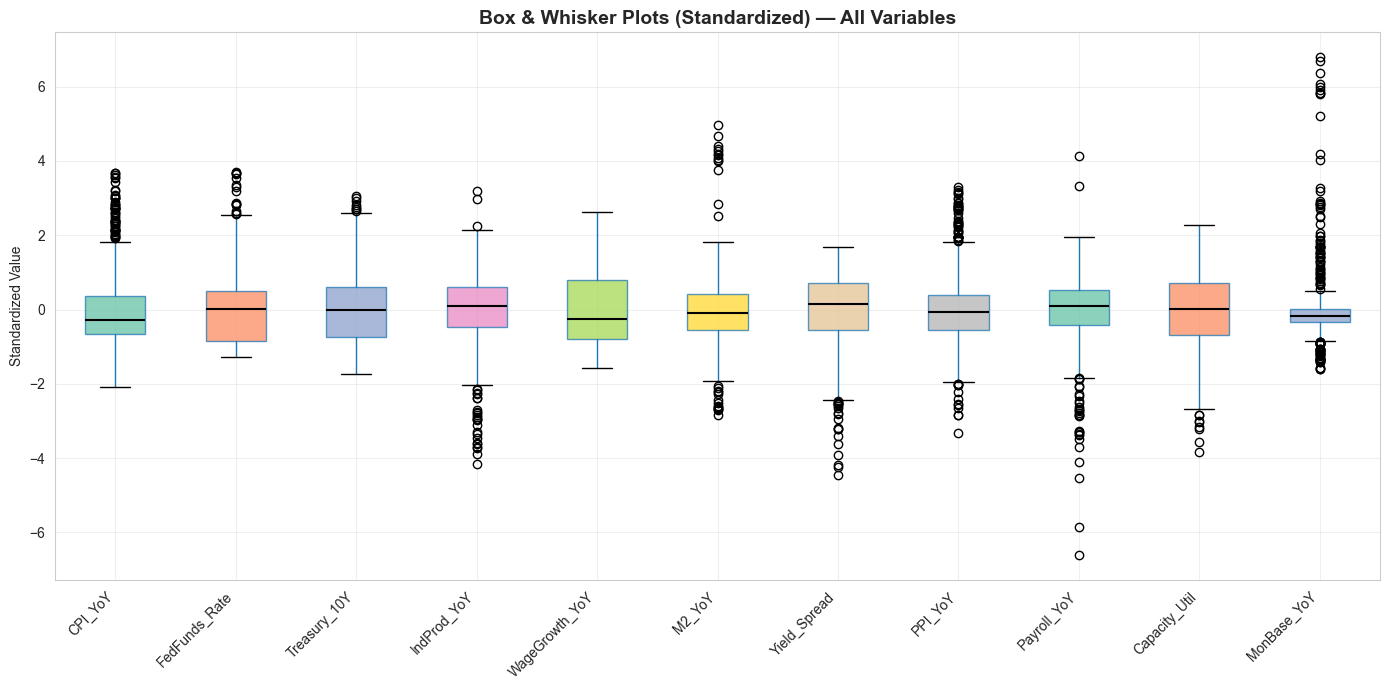


Outlier counts (IQR method):
  CPI_YoY             :  51 outliers
  FedFunds_Rate       :  15 outliers
  Treasury_10Y        :   8 outliers
  IndProd_YoY         :  27 outliers
  WageGrowth_YoY      :   0 outliers
  M2_YoY              :  27 outliers
  Yield_Spread        :  20 outliers
  PPI_YoY             :  54 outliers
  Payroll_YoY         :  30 outliers
  Capacity_Util       :   8 outliers
  MonBase_YoY         : 107 outliers


In [ ]:
# Standardize all variables to the same scale so the box plots are readable side by side

scaler = StandardScaler()
df_z = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

palette = sns.color_palette("Set2", n_colors=len(df.columns))

fig, ax = plt.subplots(figsize=(14, 7))
bp = df_z.boxplot(ax=ax, patch_artist=True, return_type="dict")

for i, (box, med) in enumerate(zip(bp["boxes"], bp["medians"])):
    box.set_facecolor(palette[i])
    box.set_alpha(0.75)
    med.set_color("black")
    med.set_linewidth(1.5)

ax.set_title("Box & Whisker Plots (Standardized) — All Variables",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Standardized Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./Box & Whisker Plots (Standardized) All Variables.png", bbox_inches="tight", dpi=150)
plt.show()


# Count how many data points fall outside the 1.5x IQR fence for each variable
print("\nOutlier counts (IQR method):")
for col in df.columns:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col:20s}: {n_out:3d} outliers")


---
## Task 4 Scatter Plot Grid (each Independant Var vs CPI)

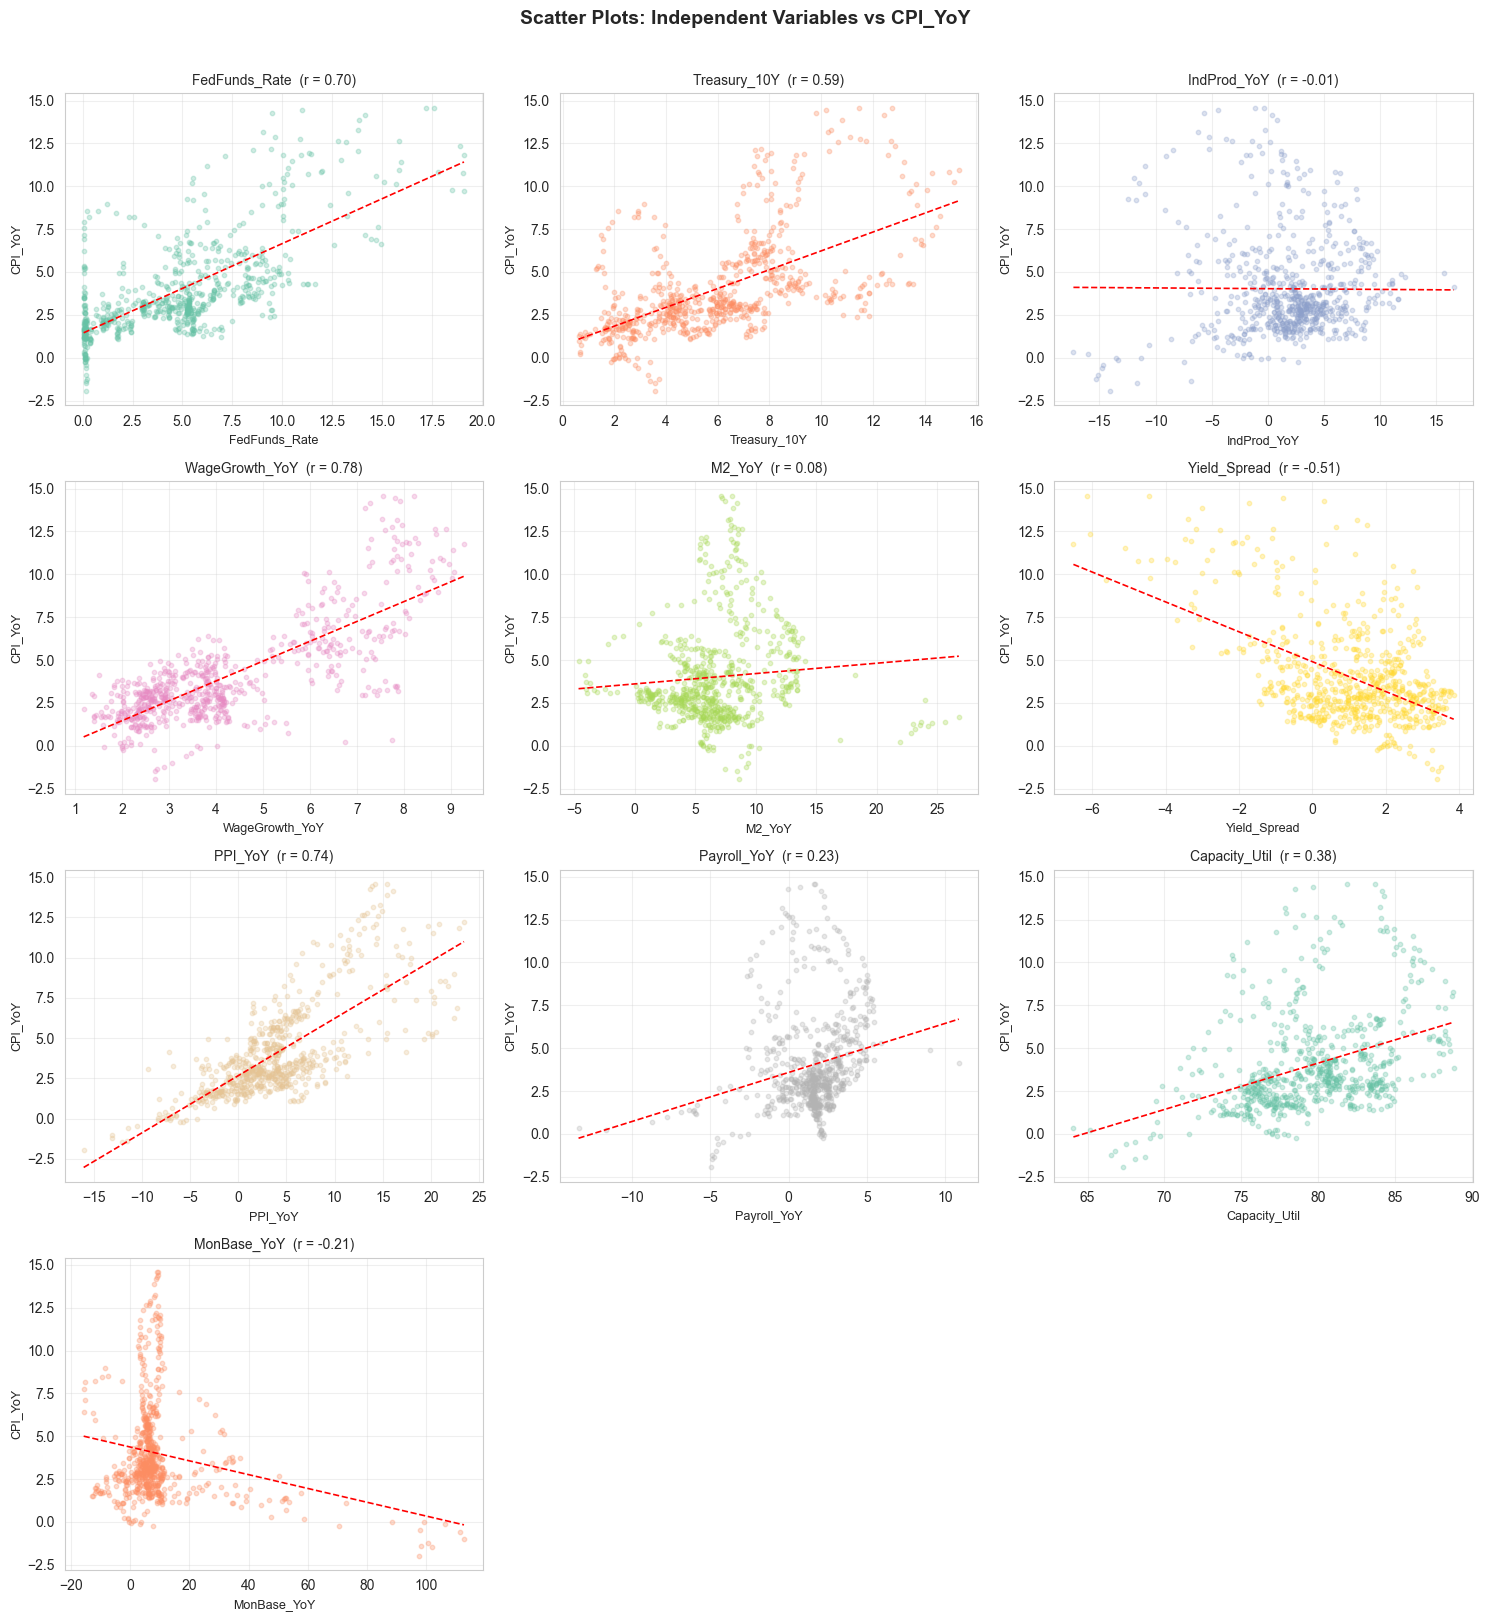

In [17]:
indep_cols = [c for c in df.columns if c != DEPENDENT]
n = len(indep_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()

for i, col in enumerate(indep_cols):
    ax = axes_flat[i]
    ax.scatter(df[col], df[DEPENDENT], alpha=0.3, s=10,
               color=palette[i % len(palette)])
    z = np.polyfit(df[col], df[DEPENDENT], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xs, np.polyval(z, xs), "r--", lw=1.2)
    r = df[col].corr(df[DEPENDENT])
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel(DEPENDENT, fontsize=9)
    ax.set_title(f"{col}  (r = {r:.2f})", fontsize=10)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f"Scatter Plots: Independent Variables vs {DEPENDENT}",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./fig_scatter.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Task 5a Correlation Matrix & Multicollinearity Removal

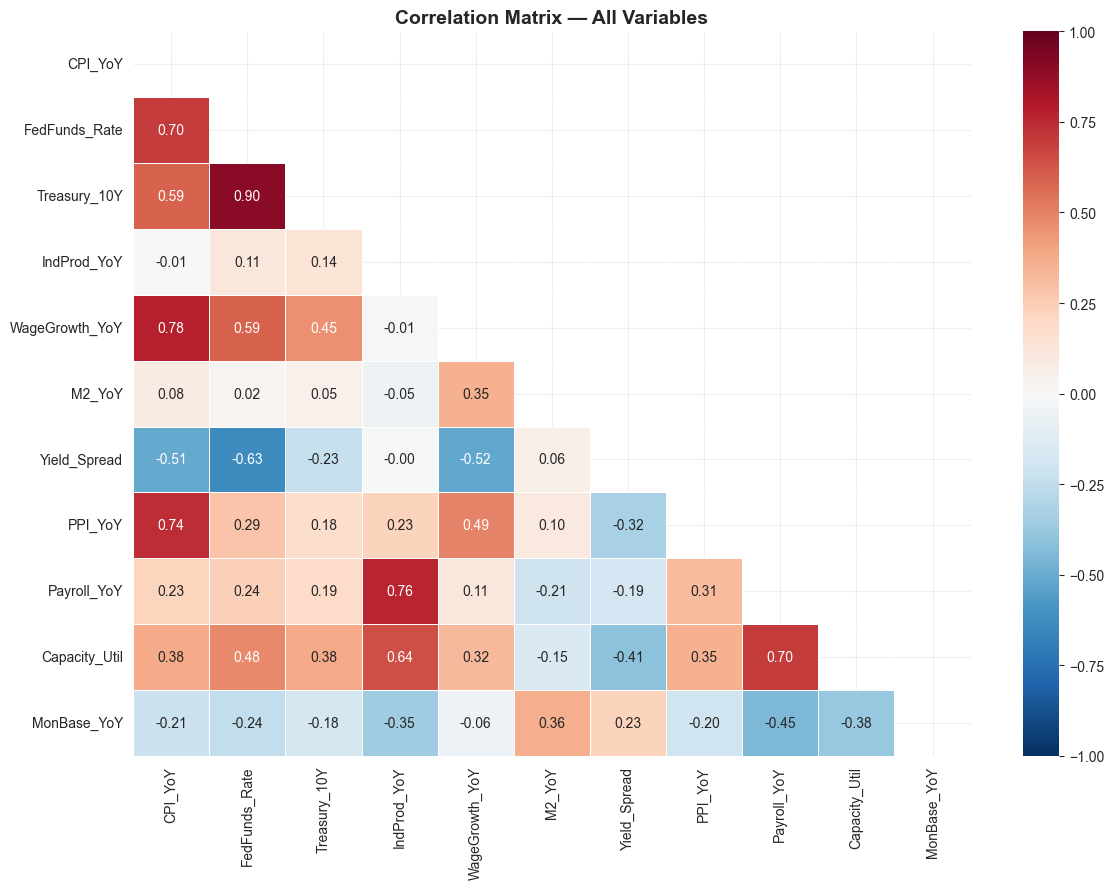

In [ ]:
# Build the correlation heatmap
# This helps us spot which variables are highly correlated with each other before modeling

corr_full = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix All Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./Correlation Matrix All Variables.png", bbox_inches="tight", dpi=150)
plt.show()


In [19]:
# Remove redundant features - keeping both would not add information and can hurt the model

# When two features are too correlated, drop the one that is more broadly correlated with everything else

indep_cols = [c for c in df.columns if c != DEPENDENT]
corr_indep = df[indep_cols].corr().abs()

dropped = set()
drop_log = []

for i in range(len(indep_cols)):
    if indep_cols[i] in dropped:
        continue
    for j in range(i + 1, len(indep_cols)):
        if indep_cols[j] in dropped:
            continue
        r = corr_indep.iloc[i, j]
        if r > CORR_THRESHOLD:
            avg_i = corr_indep.iloc[i].drop(indep_cols[i]).mean()
            avg_j = corr_indep.iloc[j].drop(indep_cols[j]).mean()
            to_drop = indep_cols[i] if avg_i > avg_j else indep_cols[j]
            kept    = indep_cols[j] if to_drop == indep_cols[i] else indep_cols[i]
            dropped.add(to_drop)
            drop_log.append(
                f"  DROPPED  '{to_drop}'  (avg |r| = {max(avg_i, avg_j):.3f})"
                f"  —  correlated with '{kept}' at |r| = {r:.3f}"
            )

print(f"Threshold : |r| > {CORR_THRESHOLD}")
print(f"Dropped   : {len(dropped)} variable(s)\n")
for line in drop_log:
    print(line)

# Assemble the final feature set after dropping the redundant columns
keep_cols = [DEPENDENT] + [c for c in indep_cols if c not in dropped]
df_model = df[keep_cols].copy()

print(f"\nColumns for modeling ({len(df_model.columns)}):")
print(f"  Dependent  : {DEPENDENT}")
print(f"  Independent: {[c for c in keep_cols if c != DEPENDENT]}")


Threshold : |r| > 0.75
Dropped   : 2 variable(s)

  DROPPED  'FedFunds_Rate'  (avg |r| = 0.389)  —  correlated with 'Treasury_10Y' at |r| = 0.903
  DROPPED  'Payroll_YoY'  (avg |r| = 0.351)  —  correlated with 'IndProd_YoY' at |r| = 0.763

Columns for modeling (9):
  Dependent  : CPI_YoY
  Independent: ['Treasury_10Y', 'IndProd_YoY', 'WageGrowth_YoY', 'M2_YoY', 'Yield_Spread', 'PPI_YoY', 'Capacity_Util', 'MonBase_YoY']


---
## Task 5b Train / Test Split (time-ordered)

In [20]:
# Time series data must be split chronologically - shuffling would leak future information into training

split_idx = int(len(df_model) * (1 - TEST_RATIO))

train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

y_train, X_train = train[DEPENDENT], train.drop(columns=[DEPENDENT])
y_test,  X_test  = test[DEPENDENT],  test.drop(columns=[DEPENDENT])

# Hold on to the dates so we can use them on the x-axis of the prediction plots
dates_train = train.index
dates_test  = test.index

print(f"Train : {len(train)} rows  ({dates_train.min().date()} → {dates_train.max().date()})")
print(f"Test  : {len(test)} rows   ({dates_test.min().date()} → {dates_test.max().date()})")


Train : 548 rows  (1969-01-01 → 2014-08-01)
Test  : 138 rows   (2014-09-01 → 2026-03-01)


---
## Task 5c Model 1: ARIMAX

In [21]:


arimax_model = SARIMAX(
    endog=y_train.values,
    exog=X_train.values,
    order=ARIMAX_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  548
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 -82.288
Date:                Mon, 11 May 2026   AIC                            186.575
Time:                        11:36:43   BIC                            233.904
Sample:                             0   HQIC                           205.076
                                - 548                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1280      0.041      3.159      0.002       0.049       0.207
x2            -0.0347      0.013     -2.653      0.008      -0.060      -0.009
x3             0.0903      0.037      2.456      0.0

In [22]:
# Run the fitted ARIMAX model on the held-out test period and compute error metrics

arimax_pred_vals = arimax_fit.forecast(steps=len(y_test), exog=X_test.values)


arimax_pred = pd.Series(arimax_pred_vals, index=dates_test, name="ARIMAX_pred")

arimax_mse  = mean_squared_error(y_test, arimax_pred)
arimax_rmse = np.sqrt(arimax_mse)
arimax_mae  = mean_absolute_error(y_test, arimax_pred)
arimax_r2   = r2_score(y_test, arimax_pred)

print("ARIMAX — Test Performance")
print(f"  MSE  : {arimax_mse:.4f}")
print(f"  RMSE : {arimax_rmse:.4f}")
print(f"  MAE  : {arimax_mae:.4f}")
print(f"  R²   : {arimax_r2:.4f}")


ARIMAX — Test Performance
  MSE  : 0.8386
  RMSE : 0.9157
  MAE  : 0.7468
  R²   : 0.8168


---
## Task 5d Model 2: Random Forest

In [23]:


rf_model = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    random_state=RF_RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

rf_pred_vals = rf_model.predict(X_test)
rf_pred = pd.Series(rf_pred_vals, index=dates_test, name="RF_pred")

rf_mse  = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest — Test Performance")
print(f"  MSE  : {rf_mse:.4f}")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  R²   : {rf_r2:.4f}")

Random Forest — Test Performance
  MSE  : 1.6173
  RMSE : 1.2717
  MAE  : 0.8646
  R²   : 0.6467


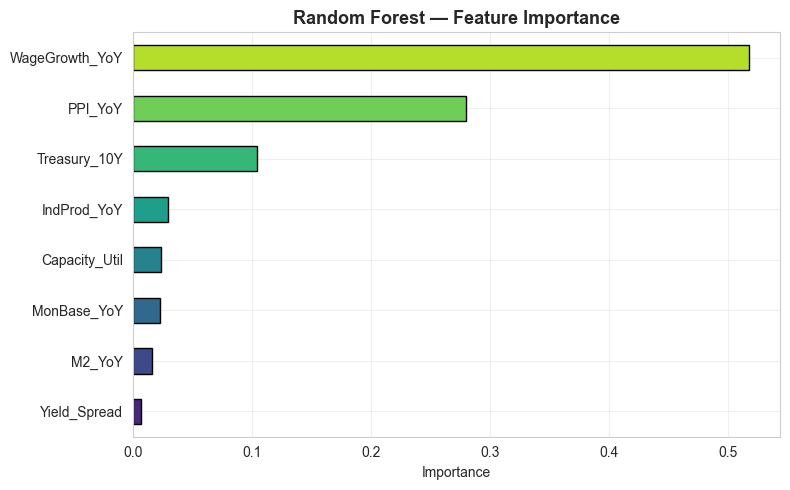

In [ ]:
# Show which features the Random Forest relied on most 

importance = pd.Series(rf_model.feature_importances_,
                       index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color=sns.color_palette("viridis", len(importance)),
                     edgecolor="black")
ax.set_title("Random Forest — Feature Importance", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("./Feature Importance.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Task 5e Model Comparison

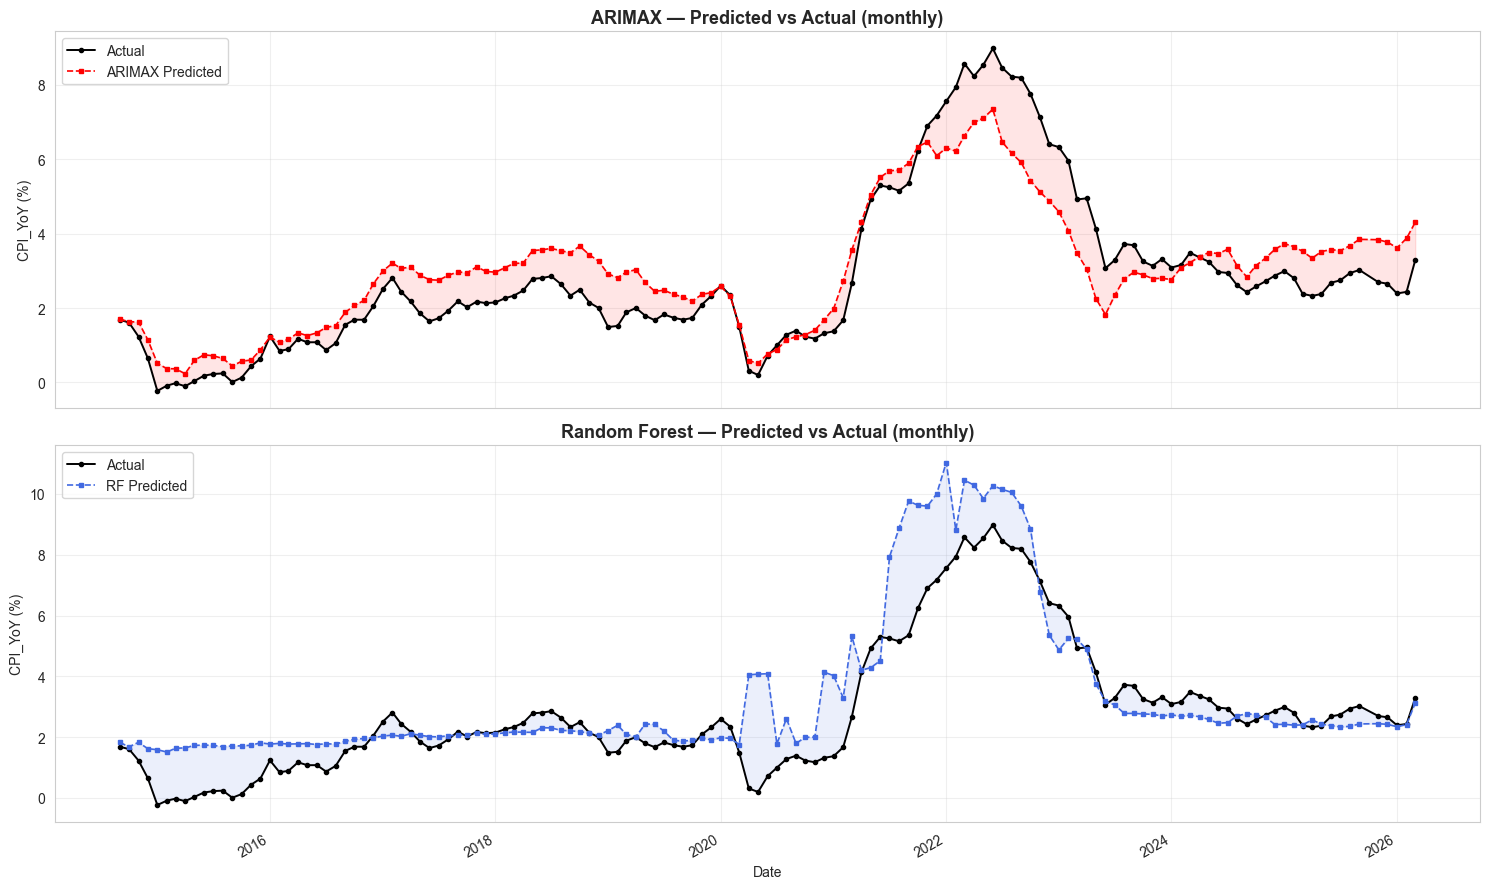

In [25]:
# Side-by-side plots of predicted vs actual values for both models

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Top panel: ARIMAX predictions vs actual CPI
axes[0].plot(dates_test, y_test.values, color="black", lw=1.4,
             marker="o", ms=3, label="Actual")
axes[0].plot(dates_test, arimax_pred.values, color="red", lw=1.2,
             marker="s", ms=2.5, ls="--", label="ARIMAX Predicted")
axes[0].fill_between(dates_test, y_test.values, arimax_pred.values,
                     alpha=0.10, color="red")
axes[0].set_title("ARIMAX — Predicted vs Actual (monthly)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel(f"{DEPENDENT} (%)")
axes[0].legend(loc="upper left")

# Bottom panel: Random Forest predictions vs actual CPI
axes[1].plot(dates_test, y_test.values, color="black", lw=1.4,
             marker="o", ms=3, label="Actual")
axes[1].plot(dates_test, rf_pred.values, color="royalblue", lw=1.2,
             marker="s", ms=2.5, ls="--", label="RF Predicted")
axes[1].fill_between(dates_test, y_test.values, rf_pred.values,
                     alpha=0.10, color="royalblue")
axes[1].set_title("Random Forest — Predicted vs Actual (monthly)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel(f"{DEPENDENT} (%)")
axes[1].legend(loc="upper left")

plt.xlabel("Date")
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("./ARIMAX and RANDOM FOREST PRED vs ACTUAL.png", bbox_inches="tight", dpi=150)
plt.show()


In [26]:
# Print a side-by-side table of error metrics for both models

metrics = pd.DataFrame({
    "ARIMAX":        [arimax_mse, arimax_rmse, arimax_mae, arimax_r2],
    "Random Forest": [rf_mse, rf_rmse, rf_mae, rf_r2],
}, index=["MSE", "RMSE", "MAE", "R²"])

print("Model Comparison:\n")
print(metrics.round(4).to_string())


Model Comparison:

      ARIMAX  Random Forest
MSE   0.8386         1.6173
RMSE  0.9157         1.2717
MAE   0.7468         0.8646
R²    0.8168         0.6467


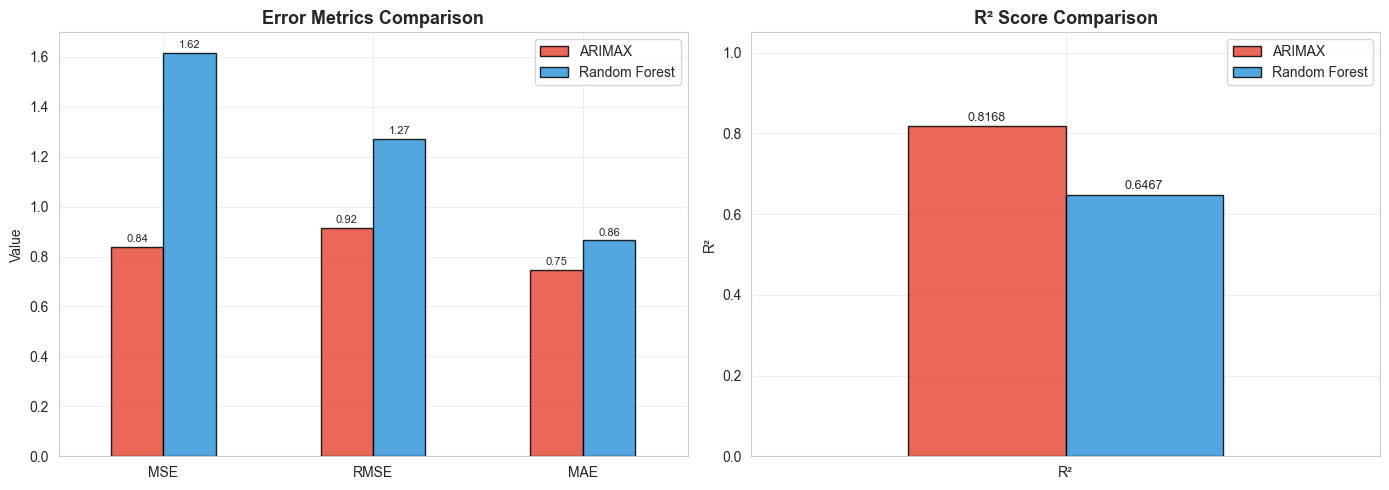

In [27]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#e74c3c", "#3498db"]

# Left chart: compare MSE, RMSE, and MAE between the two models
err = metrics.loc[["MSE", "RMSE", "MAE"]]
err.plot.bar(ax=axes[0], rot=0, color=colors, edgecolor="black", alpha=0.85)
axes[0].set_title("Error Metrics Comparison", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Value")
for ctr in axes[0].containers:
    axes[0].bar_label(ctr, fmt="%.2f", fontsize=8, padding=2)

# Right chart: compare R-squared scores - higher is better, can go negative if the model is bad
r2_df = metrics.loc[["R²"]]
r2_df.plot.bar(ax=axes[1], rot=0, color=colors, edgecolor="black", alpha=0.85)
axes[1].set_title("R² Score Comparison", fontsize=13, fontweight="bold")
axes[1].set_ylabel("R²")
axes[1].set_ylim(min(0, metrics.loc["R²"].min() - 0.1), 1.05)
for ctr in axes[1].containers:
    axes[1].bar_label(ctr, fmt="%.4f", fontsize=9, padding=2)

plt.tight_layout()
plt.savefig("./error metrics.png", bbox_inches="tight", dpi=150)
plt.show()


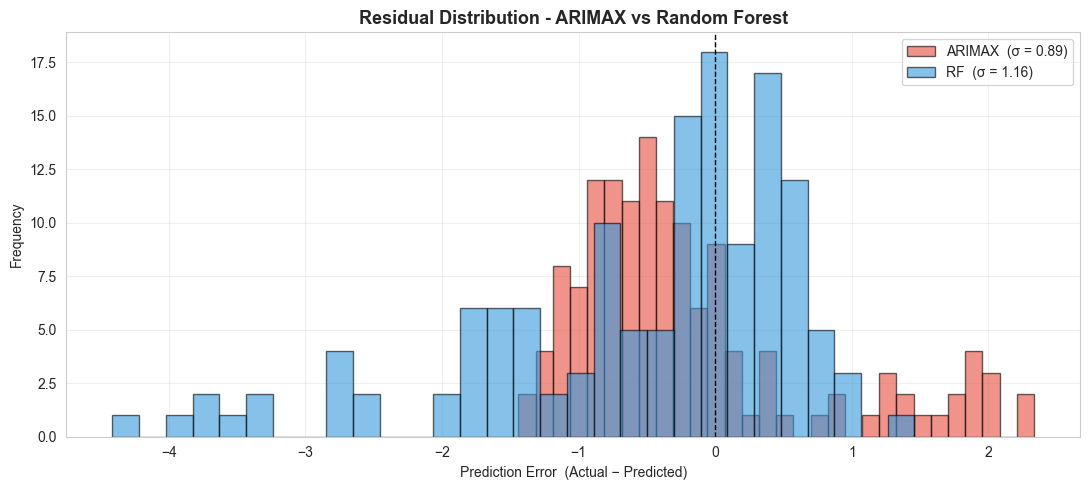

In [28]:
# Overlay the residual distributions for both models to see how errors are spread

arimax_resid = y_test.values - arimax_pred.values
rf_resid     = y_test.values - rf_pred.values

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(arimax_resid, bins=30, alpha=0.6, color="#e74c3c", edgecolor="black",
        label=f"ARIMAX  (σ = {np.std(arimax_resid):.2f})")
ax.hist(rf_resid, bins=30, alpha=0.6, color="#3498db", edgecolor="black",
        label=f"RF  (σ = {np.std(rf_resid):.2f})")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_title("Residual Distribution - ARIMAX vs Random Forest",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Prediction Error  (Actual − Predicted)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("./fig_residuals.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Results & Conclusion

In [29]:
print("=" * 62)
print("  FINAL MODEL COMPARISON SUMMARY")
print("=" * 62)
print(f"\n  Dependent Variable : {DEPENDENT}")
print(f"  Independents Used  : {list(X_train.columns)}")
print(f"  Dropped (|r|>{CORR_THRESHOLD})  : {sorted(dropped) if dropped else 'None'}")
print(f"  Train / Test       : {len(y_train)} / {len(y_test)} observations")
print()
print(f"  {'Metric':<8} {'ARIMAX':>12}  {'Random Forest':>15}")
print(f"  {'-'*40}")
for m in ["MSE", "RMSE", "MAE", "R²"]:
    print(f"  {m:<8} {metrics.loc[m, 'ARIMAX']:>12.4f}  "
          f"{metrics.loc[m, 'Random Forest']:>15.4f}")

winner = "ARIMAX" if arimax_mse < rf_mse else "Random Forest"
print(f"\n  ➜  Based on MSE, {winner} performs better on the test set.")
print("=" * 62)

  FINAL MODEL COMPARISON SUMMARY

  Dependent Variable : CPI_YoY
  Independents Used  : ['Treasury_10Y', 'IndProd_YoY', 'WageGrowth_YoY', 'M2_YoY', 'Yield_Spread', 'PPI_YoY', 'Capacity_Util', 'MonBase_YoY']
  Dropped (|r|>0.75)  : ['FedFunds_Rate', 'Payroll_YoY']
  Train / Test       : 548 / 138 observations

  Metric         ARIMAX    Random Forest
  ----------------------------------------
  MSE            0.8386           1.6173
  RMSE           0.9157           1.2717
  MAE            0.7468           0.8646
  R²             0.8168           0.6467

  ➜  Based on MSE, ARIMAX performs better on the test set.
